In [1]:
#effecient Frontier 

In [2]:
%load_ext autoreload
%autoreload 2

import edhec_risk_kit as erk
ind = erk.get_ind_returns()
er = erk.annualize_rets(ind['1995':'2000'], 12)
cov = ind['1995':'2000'].cov()

C:\Users\delni\edhec_risk_kit.py:46: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  ind = pd.read_csv('ind30_m_vw_rets.csv', header = 0, index_col= 0, parse_dates= True)/100


In [3]:
def portfolio_return(weights, returns):
    """
    Weights -> returns
    """
    return weight.T @ returns
def portfolio_vol(weights, covmat):
    """
    weights -> vol
    """
    return (weights.T @ covmat @ weights)**0.5

In [4]:
l = ['Food', 'Beer', 'Smoke', 'Coal']
er[l]

Food     0.157362
Beer     0.190134
Smoke    0.129288
Coal     0.343089
dtype: float64

In [5]:
cov.loc[l,l]

,Food,Beer,Smoke,Coal
Food,0.002287,0.002077,0.001757,0.000034
Beer,0.002077,0.004599,0.001143,0.001261
Smoke,0.001757,0.001143,0.007130,-0.000544
Coal,0.000034,0.001261,-0.000544,0.016153


In [6]:
import numpy as np
weights = np.repeat(1/4, 4)

In [7]:
weights

array([0.25, 0.25, 0.25, 0.25])

In [8]:
erk.portfolio_return(weights, er[l])

np.float64(0.20496820684146116)

In [9]:
erk.portfolio_vol(weights, cov.loc[l,l])

np.float64(0.05100412722141178)

In [10]:
#2 Asset Fontier

In [11]:
l = ['Games', 'Fin']

In [12]:
n_points = 20
weights = [np.array([w, 1-w]) for w in np.linspace(0, 1, n_points)]

In [13]:
weights

[array([0., 1.]),
 array([0.05263158, 0.94736842]),
 array([0.10526316, 0.89473684]),
 array([0.15789474, 0.84210526]),
 array([0.21052632, 0.78947368]),
 array([0.26315789, 0.73684211]),
 array([0.31578947, 0.68421053]),
 array([0.36842105, 0.63157895]),
 array([0.42105263, 0.57894737]),
 array([0.47368421, 0.52631579]),
 array([0.52631579, 0.47368421]),
 array([0.57894737, 0.42105263]),
 array([0.63157895, 0.36842105]),
 array([0.68421053, 0.31578947]),
 array([0.73684211, 0.26315789]),
 array([0.78947368, 0.21052632]),
 array([0.84210526, 0.15789474]),
 array([0.89473684, 0.10526316]),
 array([0.94736842, 0.05263158]),
 array([1., 0.])]

In [14]:
len(weights)

20

<Axes: xlabel='Vol', ylabel='R'>

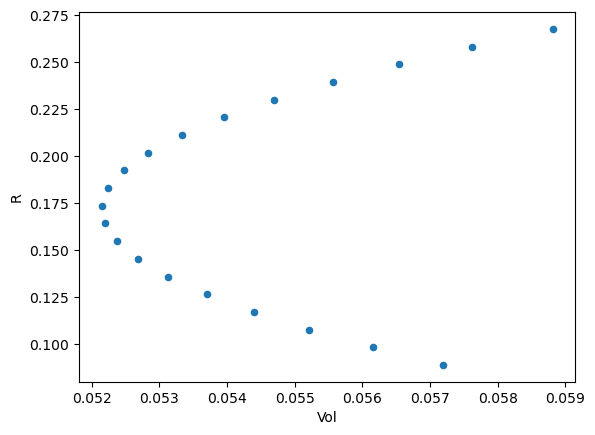

In [15]:
import pandas as pd
rets = [erk.portfolio_return(w, er[l]) for w in weights]
vols = [erk.portfolio_vol(w, cov.loc[l,l]) for w in weights]
ef = pd.DataFrame({'R': rets, 'Vol': vols})
ef.plot.scatter(x='Vol',y='R')

<Axes: xlabel='Vol'>

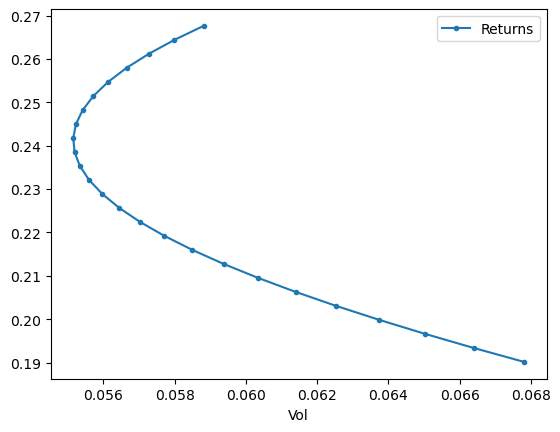

In [16]:
l = ['Fin', 'Beer']
erk.plot_ef2(25, er[l], cov.loc[l,l])